In [1]:
!TZ=America/Chicago date

Tue Feb 18 19:21:43 CST 2020


In [ ]:
%matplotlib notebook
"""
Load the code base.
"""
%run    ./Code/bs.py
%run -i ./Code/rates.py
%run -i ./Code/derivative.py
%run -i ./Code/solver.py
%run -i ./Code/binned_mixture.py
%run -i ./Code/equilibria.py
"""
Suppress automatic display of graphics generated by Matplotlib. All
graphics are saved to disk, and are displayed by explicit commands.
NOT!!!
"""
plt.interactive(True)
"""
Define the name of the subdirectory that holds various files associated
with this notebook, and create the directory if it does not exist already.
"""
DIR = './finite_sim_data/'
!if [ ! -d {DIR} ]; then mkdir {DIR}; fi

# Random finite

In [31]:
class FiniteSim(object):
    """
    Base class.
    
    Requires that `capacity' method be defined by subclass.
    """
    def __init__(self, rates, mutation_matrix, init_dist, steps_per_year=1,
                       max_size=1e9, init_size=None):
                       # init_mean=0.044, init_std=0.005):
        self.rates = rates
        self.n = len(rates.fitness)
        self.u = np.array(mutation_matrix.T)
        self.init_dist = init_dist
        self.steps_per_year = steps_per_year
        self.birth_rates = self.rates.birth / steps_per_year
        self.death_rate = self.rates.death / steps_per_year
        self.birthing = self.birth_rates * mutation_matrix
        self.max_size = max_size
        if init_size is None:
            init_size = max_size
        elif init_size > max_size:
            raise Exception('Initial pop size greater than max size')
        # self.init_mean = init_mean
        # self.init_std = init_std
        # p = normal_pdf(rates.fitness, init_mean, init_std)
        # p = (p / fsum(p)).astype(float)
        self.freqs = rand.multinomial(init_size, init_dist)
        self.n_years = 0
        self.results = np.empty((1, len(self.freqs)), dtype=int)
        self.results[self.n_years] = self.freqs


    def run(self, n_years):
        """
        SLOW!
        """
        self._allocate_memory(n_years)
        freqs = self.freqs
        for _ in range(n_years):
            for _ in range(self.steps_per_year):
                pop_size = np.sum(freqs)
                if pop_size == 0:
                    return
                expect_deaths = self.death_rate * pop_size
                #
                # Numbers of unmutated births are Poisson distributed.
                lambdas = self.birth_rates * freqs
                expect_births = fsum(lambdas)
                p = lambdas / expect_births
                #
                # Adjust expected numbers of births and deaths to keep
                # expected pop size from exceeding carrying capacity.
                expect_deaths, expect_births = \
                    self.capacity(pop_size, expect_deaths, expect_births)
                #
                # Numbers of deaths are binomially distributed.
                d = expect_deaths / pop_size
                n_deaths = [rand.binomial(n, d) for n in freqs]
                #
                # Numbers of unmutated births are Poisson distributed.
                total_births = stats.poisson.rvs(expect_births)
                n_births = rand.multinomial(total_births, p)
                #
                # Add numbers of mutated births to frequencies.
                for j in range(self.n):
                    if n_births[j] > 0:
                        freqs += rand.multinomial(n_births[j], self.u[j])
                #
                # Subtract numbers of deaths from frequencies.
                np.subtract(freqs, n_deaths, out=freqs)
            self.n_years += 1
            self.results[self.n_years] = freqs


    def __call__(self, n_years):
        """
        FAST!
        """
        self._allocate_memory(n_years)
        freqs = self.freqs
        for _ in range(n_years):
            for _ in range(self.steps_per_year):
                pop_size = np.sum(freqs)
                if pop_size == 0:
                    return
                expect_deaths = self.death_rate * pop_size
                #
                # Numbers of mutant births are Poisson distributed.
                lambdas = np.dot(self.birthing, freqs)
                expect_births = fsum(lambdas)
                p = lambdas / expect_births
                #
                # Adjust expected numbers of births and/or deaths to keep
                # expected pop size from exceeding carrying capacity.
                expect_deaths, expect_births = \
                    self.capacity(pop_size, expect_deaths, expect_births)
                #
                # Numbers of deaths are binomially distributed.
                d = expect_deaths / pop_size
                n_deaths = rand.binomial(freqs, d)
                #
                # Numbers of mutant births are Poisson distributed.
                total_births = stats.poisson.rvs(expect_births)
                n_mutants = rand.multinomial(total_births, p)
                #
                # Update the frequencies.
                np.add(freqs, n_mutants, out=freqs)
                np.subtract(freqs, n_deaths, out=freqs)
            self.n_years += 1
            self.results[self.n_years] = freqs

    def _allocate_memory(self, n):
        rows, cols = self.results.shape
        new = np.zeros((rows+n, cols), dtype=int)
        new[:rows] = self.results
        self.results = new

    def _excess(self, pop_size, expected_deaths, expected_births):
        expected_size = pop_size - expected_deaths + expected_births
        return max(0, expected_size - self.max_size)

    def __getitem__(self, which):
        return self.results[which]
    
    def __len__(self):
        return len(self.results)
    
class VariableBirthRates(FiniteSim):
    def capacity(self, pop_size, expected_deaths, expected_births):
        excess = self._excess(pop_size, expected_deaths, expected_births)
        return expected_deaths, max(0, expected_births - excess)

class VariableDeathRate(FiniteSim):
    def capacity(self, pop_size, expected_deaths, expected_births):
        """excess = self._excess(pop_size, expected_deaths, expected_births)
        return expected_deaths + excess, expected_births"""
        expected_deaths = max(expected_deaths, pop_size - self.max_size)
        return expected_deaths, expected_births
    
class LogisticBirthRates(FiniteSim):
    def capacity(self, pop_size, expected_deaths, expected_births):
        scale = max(0, 1 - (pop_size - expected_deaths) / self.max_size)
        return expected_deaths, scale * expected_births
        """scale = 1 - pop_size / self.max_size
        expected_births = expected_deaths + scale * (expected_births
                                                     - expected_deaths)
        return expected_deaths, expected_births"""

In [35]:
%%time

r = Rates(0.20, bin_width=0.0005)
p = binned_mixture(gamma_ccdf, len(r.effects), '1e-3', r.bin_width)
#comp_cdf = lambda x: 2 * normal_ccdf(x, 0, 0.001)
#p = binned_mixture(comp_cdf, len(r.effects), '0.5', r.bin_width)
p = p.astype(float)
u = Derivative.mutation_matrix(p)
eq_dist = Derivative(p, r).equilibrium()
init_dist = eq_dist
#init_dist = normal_pdf(r.fitness, 0.0, 0.012).astype(float)
#init_dist /= fsum(init_dist)
s = VariableDeathRate(r, u, init_dist, 8, max_size=1e11, init_size=None)

CPU times: user 636 ms, sys: 14.7 ms, total: 651 ms
Wall time: 321 ms


In [36]:
%%time

plt.close('all')
s(5000)

CPU times: user 1min 7s, sys: 3.35 s, total: 1min 10s
Wall time: 20.1 s


Slight difference appears at $K=10^{15}.$ Mean stays close to that of equilibrium with $K=10^{13},$ but there's considerable sloshing about of the population. Mean drops below that of equilibrium with $K=10^{12}$ (from 2.70 init to 2.58 at one time I looked at; but then I checked 10 thousand years later, and found 2.99 mean with low variance -- so the sloshing about is more pronounced). In a run with $K={11},$ the population nearly went extinct, but then recovered.

max year: 5000
Carrying capacity: 1.000000e+11
Init dist mean and var: 2.700174e-02 1.246213e-04
Init pop mean and var : 2.700176e-02 1.246210e-04
Final pop mean and var: 9.311401e-03 1.030429e-04
Final pop size        : 1.013853e+11


<IPython.core.display.Javascript object>


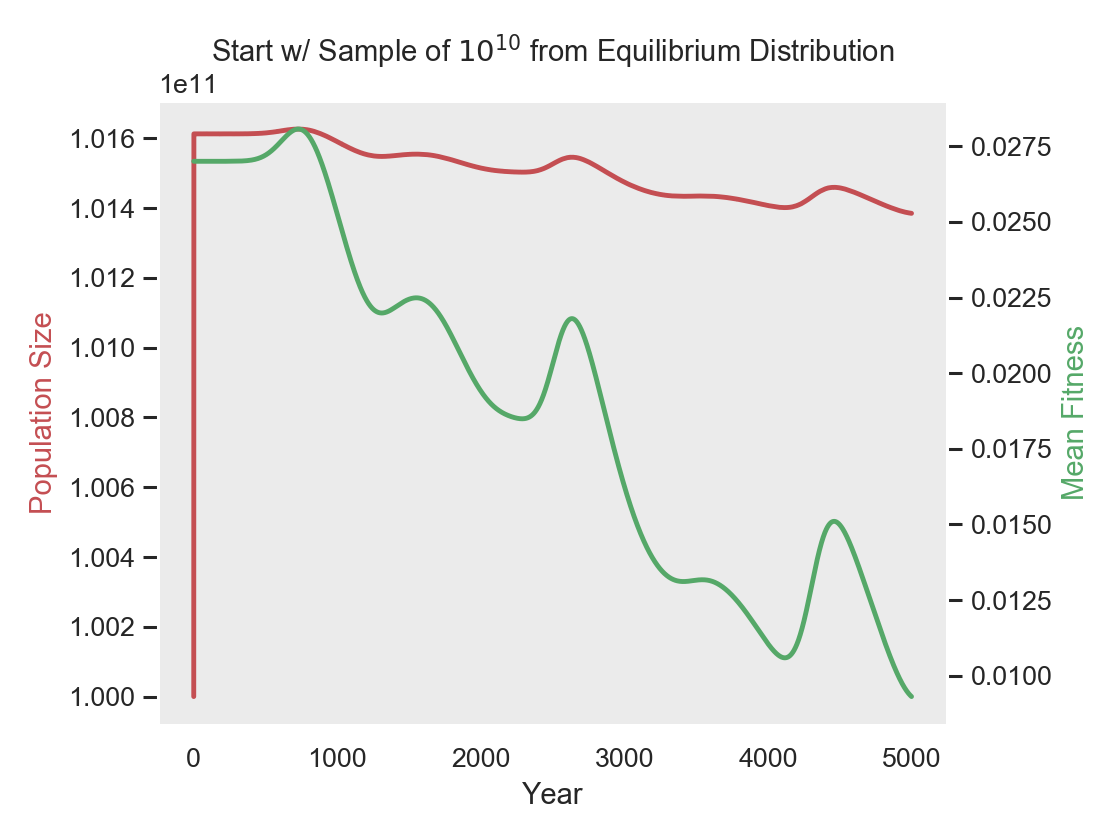

In [37]:
sizes = np.sum(s, axis=1)
n = len(sizes) - np.argmax(sizes[::-1] > 0) - 1
sizes = sizes[:n+1]
years = np.arange(n+1)
print('max year:', n)
print('Carrying capacity: {:e}'.format(s.max_size))
print('Init dist mean and var: {:e} {:e}'.format(*mean_var(s.init_dist,
                                                           r.fitness)))
print('Init pop mean and var : {:e} {:e}'.format(*mean_var(s[0],
                                                           r.fitness)))
print('Final pop mean and var: {:e} {:e}'.format(*mean_var(s[n],
                                                           r.fitness)))
print('Final pop size        : {:e}'.format(np.sum(s[n])))
plt.close()
fig, ax_size = plt.subplots()
ax_fit = ax_size.twinx()
ax_fit.grid(False)
ax_size.grid(False)
ax_size.plot(years, sizes, c='r')
ax_size.set_title('Start w/ Sample of $10^{10}$ from Equilibrium Distribution', pad=16)
ax_size.set_xlabel('Year')
ax_fit.set_ylabel('Mean Fitness', c='g')
ax_size.set_ylabel('Population Size', c='r')
m, v = mean_and_variance(r.fitness, s[:n+1] / sizes[:, None])
ax_fit.plot(years, m, c='g')
fig.tight_layout()
#plt.plot(np.arange(n+1), s[:n+1])

fig.savefig('carrying_1e10.png', format='png')

def solution(s, t):
    r = s.rates.fitness
    N0 = s[0]
    K = s.max_size * (N0 / fsum(N0))
    return (K * N0) / (N0 + (K - N0) * exp(-r * t))

<IPython.core.display.Javascript object>


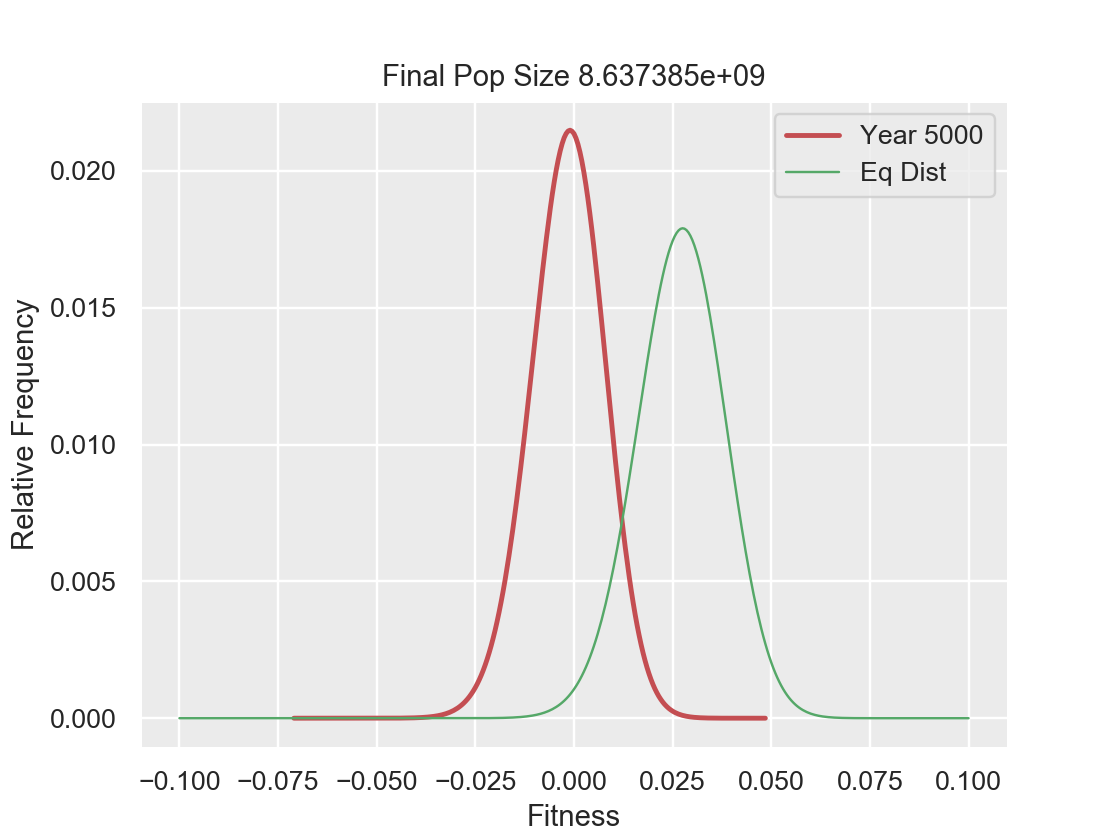

In [9]:
m = n
fig, ax = plt.subplots()
#ax.vlines(r.fitness, 0, init_dist, color='g', alpha=0.5, label='Eq Dist')
#ax.vlines(r.fitness, 0, s[m] / mp.fsum(s[m]), color='r', alpha=0.5, zorder=100,
#          label='Year {}'.format(m))
w = s[m] > 0
ax.plot(r.fitness[w], s[m, w] / mp.fsum(s[m]), color='r', zorder=100,
          label='Year {}'.format(m))
ax.plot(r.fitness, eq_dist, color='g', lw=1, label='Eq Dist', zorder=101)
ax.set_title('Final Pop Size {:e}'.format(sum(s[m])))
ax.set_ylabel('Relative Frequency')
ax.set_xlabel('Fitness')
ax.legend(loc='best')

In [11]:
sum(s.results[-1])

8637384639